## Import and diagnosis

In [ ]:
# importing pytorch
import torch

# see if cuda is available
print("PyTorch version:",torch.__version__)
print("CUDA available:",torch.cuda.is_available())
print("CUDA version",torch.version.cuda)

if torch.cuda.is_available():
    print("CUDA device count:",torch.cuda.device_count())
    print("Current CUDA device:",torch.cuda.get_device_name(0))
    print("Device:",torch.device("cuda"))
else:
    print("Device:",torch.device("cpu"))

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version 12.8
CUDA device count: 1
Current CUDA device: NVIDIA GeForce RTX 5050 Laptop GPU
Device: cuda


In [ ]:
# preparing dataset for training
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets,transforms

In [30]:
# import for creating model

# CNN
from torch import nn
from torch.nn import Sequential,Conv2d,MaxPool2d,Flatten,Linear

In [4]:
# library for visualization
import matplotlib.pyplot as plt

In [40]:
# library for timer
from timeit import default_timer as timer
from tqdm import tqdm

In [ ]:
# import for saving and loading model
import os
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

## Prepare the Data

In [3]:
# prepare datasets for training and testing
train_dataset = datasets.MNIST(root="./data",train=True,transform=transforms.ToTensor(),download=True)
test_dataset = datasets.MNIST(root="./data",train=False,transform=transforms.ToTensor(),download=True)

100%|██████████| 9.91M/9.91M [00:18<00:00, 541kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 114kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 461kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.46MB/s]


In [ ]:
# see the shape of the datasets
train_dataset.data.shape,train_dataset.targets.shape,test_dataset.data.shape,test_dataset.targets.shape

(torch.Size([60000, 28, 28]),
 torch.Size([60000]),
 torch.Size([10000, 28, 28]),
 torch.Size([10000]))

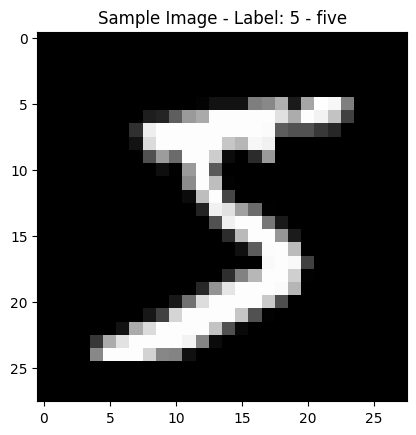

In [ ]:
# visualize a sample image from the training dataset
sample_image = train_dataset.data[0]
sample_image_label = train_dataset.targets[0]
plt.title(f"Sample Image - Label: {train_dataset.classes[sample_image_label]}")
plt.imshow(sample_image,cmap="gray")
plt.show()

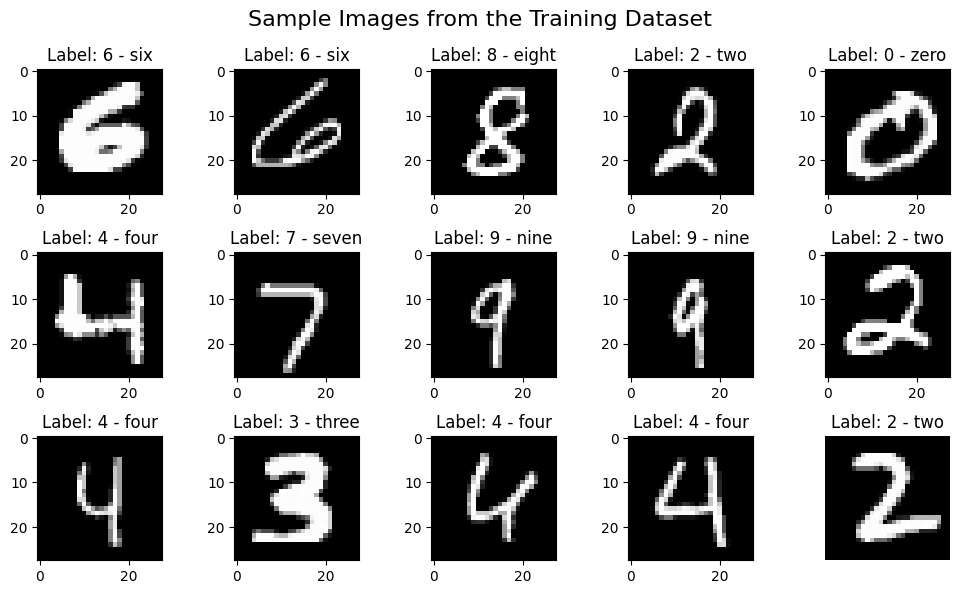

In [20]:
# visualize a number of sample images from the training dataset in 3 rows and 5 columns
# random torch seed for reproducibility
torch.manual_seed(42)


fig,axes = plt.subplots(nrows=3,ncols=5,figsize=(10,6))
plt.suptitle("Sample Images from the Training Dataset",fontsize=16)
for i,ax in enumerate(axes.flatten()):
    # get a random index from the training dataset
    random_index = torch.randint(0,len(train_dataset),(1,)).item()
    # get the image and label from the training dataset
    image,label = train_dataset[random_index]
    # plot the image
    ax.imshow(image.squeeze(),cmap="gray")
    # set the title to the label
    ax.set_title(f"Label: {train_dataset.classes[label]}")
    plt.axis("off")

plt.tight_layout()

In [22]:
# put the datasets into dataloaders
train_loader = DataLoader(dataset=train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(dataset=test_dataset,batch_size=32,shuffle=False)

In [25]:
# explore more about the dataloaders

print(f"Number of batches in train dataloader: {len(train_loader)}")
print(f"Number of batches in test dataloader: {len(test_loader)}")
print(f"Shape of a batch of images from train dataloader: {next(iter(train_loader))[0].shape}")
print(f"Shape of a batch of images from test dataloader: {next(iter(test_loader))[0].shape}")


Number of batches in train dataloader: 1875
Number of batches in test dataloader: 313
Shape of a batch of images from train dataloader: torch.Size([32, 1, 28, 28])
Shape of a batch of images from test dataloader: torch.Size([32, 1, 28, 28])


## Creating a Model

In [ ]:
# VGG Model Architecture

class VGG(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.block1 = Sequential(
            Conv2d(in_channels=in_channels, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.block2 = Sequential(
            Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.block3 = Sequential(
            Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.linear_layers = Sequential(
            Flatten(),
            Linear(in_features=256*3*3, out_features=4096),
            nn.ReLU(),
            Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            Linear(in_features=4096, out_features=num_classes)
        )
        
        
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.linear_layers(x)
        return x

In [32]:
# create function for accuracy calculation
def accuracy(y_pred, y_true):
    y_pred_classes = torch.argmax(y_pred, dim=1)
    correct = (y_pred_classes == y_true).sum().item()
    accuracy = correct / len(y_true)
    return accuracy

In [48]:
# creating function for training step and testing step

def train_step(model:nn.Module,data_loader:DataLoader,loss_fn:nn.Module,optimizer:torch.optim.Optimizer,device:torch.device):
    # set the model to training mode
    model.train()
    
    # initialize the train loss and accuracy
    train_loss,train_acc = 0,0
    
    # move the model to the device
    model.to(device)
    
    for batch, (X,y) in enumerate(data_loader):
        # move data to device
        X,y = X.to(device),y.to(device)
        
        # forward pass
        y_pred = model(X)
        
        # calculate loss
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()
        acc = accuracy(y_pred,y)
        train_acc += acc
        
        # optimizer zero grad
        optimizer.zero_grad()
        
        # loss backward
        loss.backward()
        
        # optimizer step
        optimizer.step()
    
    # calculate the average loss and accuracy
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")

def test_step(model:nn.Module,data_loader:DataLoader,loss_fn:nn.Module,device:torch.device):
    
    # initialize the test and loss accuracy
    test_loss,test_acc = 0,0
    
    # move the model to the device
    model.to(device)
        
    # set the model to evaluation mode
    model.eval()
    
    with torch.inference_mode():
        for X,y in data_loader:
            # move data to device
            X,y = X.to(device),y.to(device)
            
            # forward pass
            y_pred = model(X)
            
            # calculate loss
            loss = loss_fn(y_pred,y)
            test_loss += loss.item()
            acc = accuracy(y_pred,y)
            test_acc += acc
            
    # calculate the average loss and accuracy
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    

In [36]:
def print_train_time(start:float, end:float, device:str=None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")


In [45]:
# set the optimizer, loss function and device agnostic code

# set the device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# set the loss function
loss_fn = nn.CrossEntropyLoss()

# set the model
model = VGG(in_channels=1,num_classes=10)

# set the optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [49]:
# prepare the time start for training
train_time_start = timer()

EPOCH = 5
for epoch in tqdm(range(EPOCH)):
    print(f"Epoch: {epoch+1}/{EPOCH}")
    train_step(model=model,data_loader=train_loader,loss_fn=loss_fn,optimizer=optimizer,device=device)
    test_step(model=model,data_loader=test_loader,loss_fn=loss_fn,device=device)

train_time_end = timer()
print_train_time(start=train_time_start,end=train_time_end,device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1/5
Train Loss: 0.7006 | Train Accuracy: 0.7421


 20%|██        | 1/5 [00:23<01:32, 23.19s/it]

Test Loss: 0.0771 | Test Accuracy: 0.9776
Epoch: 2/5
Train Loss: 0.0779 | Train Accuracy: 0.9773


 40%|████      | 2/5 [00:47<01:12, 24.04s/it]

...

Test Loss: 0.0449 | Test Accuracy: 0.9884
Epoch: 4/5
Train Loss: 0.0479 | Train Accuracy: 0.9861


 80%|████████  | 4/5 [01:36<00:23, 23.96s/it]

Test Loss: 0.0355 | Test Accuracy: 0.9899
Epoch: 5/5
Train Loss: 0.0387 | Train Accuracy: 0.9884


100%|██████████| 5/5 [02:00<00:00, 24.11s/it]

Test Loss: 0.0592 | Test Accuracy: 0.9845
Train time on cuda: 116.270 seconds


## Model Evaluation

In [ ]:
def evaluate_model(model:nn.Module,data_loader:DataLoader,loss_fn:nn.Module,device:torch.device):
    # set the model to evaluation mode
    model.eval()
    
    # initialize the test loss and accuracy
    test_loss,test_acc = 0,0
    
    # move the model to the device
    model.to(device)
    
    # use inference mode to speed up the evaluation
    with torch.inference_mode():
        for X,y in data_loader:
            # move data to device
            X,y = X.to(device),y.to(device)
            
            # forward pass
            y_pred = model(X)
            
            # calculate loss
            loss = loss_fn(y_pred,y)
            test_loss += loss.item()
            acc = accuracy(y_pred,y)
            test_acc += acc
    
    # calculate the average loss and accuracy
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


    

In [51]:
# see the evaluation
evaluate_model(model=model,data_loader=test_loader,loss_fn=loss_fn,device=device)

Test Loss: 0.0592 | Test Accuracy: 0.9845


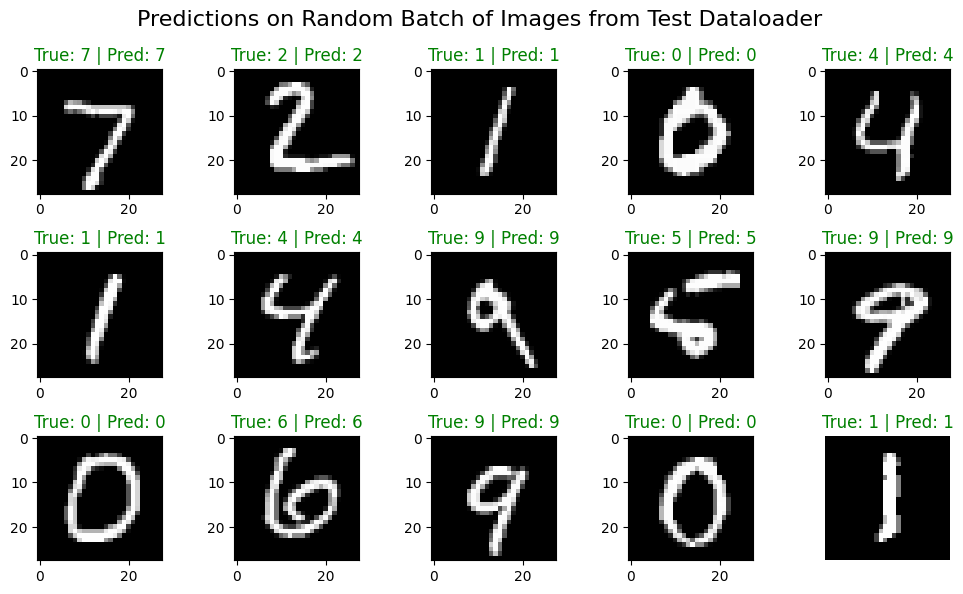

In [57]:
# show predictions for random batch of images from the test dataloader and show it in grid 3 rows and 5 columns
with torch.no_grad():
    # get a batch of images from the test dataloader
    X,y = next(iter(test_loader))
    
    # move data to device
    X,y = X.to(device),y.to(device)
    
    # get the predictions
    y_pred = model(X)
    
    # get the predicted classes
    y_pred_classes = torch.argmax(y_pred,dim=1)
    
    # move the data to cpu for visualization
    X,y,y_pred_classes = X.cpu(),y.cpu(),y_pred_classes.cpu()
    
    # plot the images in grid 3 rows and 5 columns
    fig,axes = plt.subplots(nrows=3,ncols=5,figsize=(10,6))
    plt.suptitle("Predictions on Random Batch of Images from Test Dataloader",fontsize=16)
    for i,ax in enumerate(axes.flatten()):
        ax.imshow(X[i].squeeze(),cmap="gray")
        if y[i].item() == y_pred_classes[i].item():
            ax.set_title(f"True: {y[i].item()} | Pred: {y_pred_classes[i].item()}",color="green")
        else:
            ax.set_title(f"True: {y[i].item()} | Pred: {y_pred_classes[i].item()}",color="red")
        plt.axis("off")
    
    plt.tight_layout()

In [ ]:
# save model to huggingface hub
